# ML Baseline for Student Depression Prediction
**Author:** Md. Samiul Islam, Instructor, Skill Morph Research Lab

**Dataset:** [Student Depression Dataset – Kaggle](https://www.kaggle.com/datasets/hopesb/student-depression-dataset)

**Classifiers:** Support Vector Machine (SVM) & Gaussian Naive Bayes



# 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# 2. Mount Drive & Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/StudentDepressionDataset.csv')
df.head()

Mounted at /content/drive


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


# 3. Data Preprocessing

In [3]:
# Drop irrelevant columns
df.drop(columns=['id', 'City'], inplace=True)

# Drop rows with missing values
df.dropna(inplace=True)

# Encode categorical features
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Remove near-constant (near-zero-variance) columns.
# Every record here is a student, so 'Work Pressure', 'Job Satisfaction'
# and 'Profession' are ~constant (one value in >99% of rows). After scaling,
# their rare non-zero rows become extreme outliers that dominate GaussianNB's
# per-feature likelihoods and collapse its predictions to a single class.
near_constant = [c for c in df.columns
                 if c != 'Depression'
                 and df[c].value_counts(normalize=True).iloc[0] > 0.99]
print('Dropping near-constant columns:', near_constant)
df.drop(columns=near_constant, inplace=True)

Dropping near-constant columns: ['Profession', 'Work Pressure', 'Job Satisfaction']


# 4. Train-Test Split

In [5]:
X = df.drop(columns=['Depression'])
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (22318, 12) | Test: (5580, 12)


# 5. Model Training — SVM & Naive Bayes

In [6]:
# SVM (RBF kernel with probability estimates for ROC)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print('Training complete.')

Training complete.


# 6. Evaluation Metrics — Precision, Recall, F1-Score

In [7]:
print('='*55)
print('SVM Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_svm, digits=4,
      target_names=['Not Depressed', 'Depressed']))

print('='*55)
print('Naive Bayes Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_nb, digits=4,
      target_names=['Not Depressed', 'Depressed']))

SVM Classification Report
               precision    recall  f1-score   support

Not Depressed     0.8280    0.7847    0.8058      2313
    Depressed     0.8530    0.8846    0.8685      3267

     accuracy                         0.8432      5580
    macro avg     0.8405    0.8346    0.8371      5580
 weighted avg     0.8426    0.8432    0.8425      5580

Naive Bayes Classification Report
               precision    recall  f1-score   support

Not Depressed     0.8045    0.8076    0.8060      2313
    Depressed     0.8634    0.8610    0.8622      3267

     accuracy                         0.8389      5580
    macro avg     0.8339    0.8343    0.8341      5580
 weighted avg     0.8390    0.8389    0.8389      5580



# 7. ROC-AUC Curve Comparison

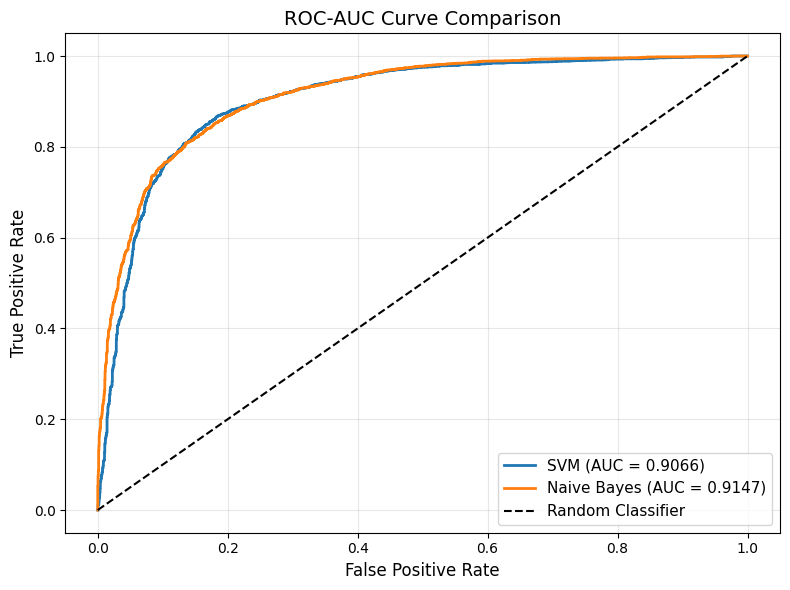

In [8]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/datasets/roc_auc_curve.png', dpi=300)
plt.show()

# 8. Results Summary Table

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ],
    'ROC-AUC': [auc_svm, auc_nb]
})

# Format to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.8432,0.8530,0.8846,0.8685,0.9066
1,Naive Bayes,0.8389,0.8634,0.8610,0.8622,0.9147


# 9. Assignment

**Dataset:** [Diabetes Prediction Dataset – Kaggle](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

**Description:** The dataset contains ~100,000 patient records with 8 medical & demographic features and a binary target (`diabetes`: 0 or 1).

**Features:** `gender`, `age`, `hypertension`, `heart_disease`, `smoking_history`, `bmi`, `HbA1c_level`, `blood_glucose_level`

---

### Tasks:
1. Download the dataset from Kaggle and upload it to your Google Drive.
2. Load & preprocess the data (handle categoricals, scale features).
3. Train **SVM** and **Naive Bayes** classifiers.
4. Evaluate using **Precision, Recall, F1-Score, and ROC-AUC Curve**.
5. Create a **Results Summary Table** comparing both models.

**Note:** Follow the same pipeline used above (Sections 1–8).